# 01 — Exploratory Data Analysis (EDA) V2

**Objetivo:** Comprender la distribución, estructura y relaciones del dataset procesado antes de construir el modelo. Este análisis guía las decisiones de feature engineering y nos permite detectar patrones comerciales en los datos de leads de 2025.

**Secciones de este notebook:**
1. Información general del dataset y estadísticas descriptivas
2. Distribución del Target (Hot Lead vs Cold Lead)
3. Análisis de variables temporales (Hora, Día de la semana, Mes)
4. Análisis de variables categóricas principales
5. Análisis temporal detallado (Heatmaps cruzados)
6. Correlación entre variables numéricas
7. Hallazgos clave y recomendaciones para Feature Engineering

**Comparativa V1 vs V2:**
- **Versión 2:** Analizamos ~62,500 registros depurados del año 2025. Sin chatbot y con una depuración más consistente, obtenemos una visión más realista del comportamiento comercial observado en esta ejecución.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
df = pd.read_csv("../data/processed/leads_cleaned.csv")
print(f"Dataset V2 cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas")

Dataset V2 cargado: 58,546 filas x 12 columnas


## 1. Información General del Dataset y Estadísticas Descriptivas

Se revisa la estructura del dataset procesado: tipos de datos, valores nulos residuales y estadísticas descriptivas para variables numéricas y categóricas. Esta es la base para validar que el Data Engineering funcionó correctamente y entender el rango de valores con los que trabajará el modelo.

In [16]:
df.info()
print("\nValores Nulos por Columna:")
print(df.isnull().sum())
print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
print("\n--- Numéricas ---")
print(df.describe().to_string())
print("\n--- Categóricas ---")
print(df.describe(include='object').to_string())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58546 entries, 0 to 58545
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   nombre_formulario    58546 non-null  object
 1   campana              58546 non-null  object
 2   origen_creacion      58546 non-null  object
 3   subtipo_interes      58546 non-null  object
 4   vehiculo_interes     58546 non-null  object
 5   concesionario        58546 non-null  object
 6   origen               58546 non-null  object
 7   mes_creacion         58546 non-null  int64 
 8   dia_creacion         58546 non-null  int64 
 9   hora_creacion        58546 non-null  int64 
 10  dia_semana_creacion  58546 non-null  object
 11  target               58546 non-null  int64 
dtypes: int64(4), object(8)
memory usage: 5.4+ MB

Valores Nulos por Columna:
nombre_formulario      0
campana                0
origen_creacion        0
subtipo_interes        0
vehiculo_interes       0
co

**Hallazgos:**
- El dataset no debería tener valores nulos ya que fueron imputados con `'Desconocido'` en el paso anterior. Si aparecen, revisar el pipeline de Data Engineering.
- Las variables numéricas (`hora_creacion`, `mes_creacion`, `dia_creacion`) deben mostrar rangos lógicos (0-23 para hora, 1-12 para mes, etc.).
- Las variables categóricas con muchos valores únicos (`campana`, `concesionario`) confirman la necesidad de estrategias de encoding sofisticadas en el siguiente notebook.

**Diferencias V1 vs V2:**
La V1 tenía columnas adicionales como `anio_creacion` y `plataforma`. En la V2 el dataset es más compacto, pero `subtipo_interes` sigue presente en los resultados mostrados, por lo que su posible riesgo de data leakage debe validarse explícitamente antes de usarla en modelado.

## 2. Distribución del Target (Hot Lead vs Cold Lead)

La variable objetivo `target` es binaria: **1 = Hot Lead** (lead con intención de compra confirmada) y **0 = Cold Lead** (rechazo o sin contacto exitoso). Entender su distribución es crítico para elegir las métricas de evaluación del modelo y decidir si se requieren técnicas de balanceo de clases.

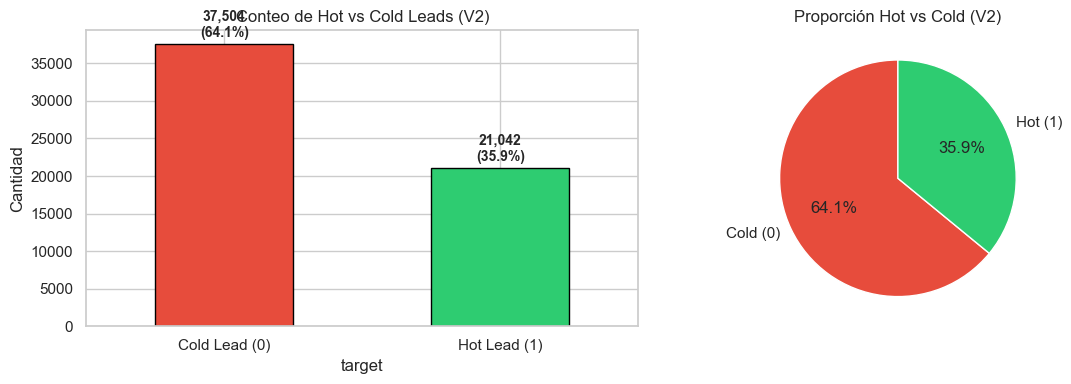

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df["target"].value_counts()
bars = counts.plot(kind="bar", color=["#e74c3c", "#2ecc71"], edgecolor="black", ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Cold Lead (0)", "Hot Lead (1)"], rotation=0)
axes[0].set_title("Conteo de Hot vs Cold Leads (V2)")
axes[0].set_ylabel("Cantidad")

total = len(df)
for i, (val, cnt) in enumerate(counts.items()):
    pct = cnt / total * 100
    axes[0].text(i, cnt + total*0.01, f"{cnt:,}\n({pct:.1f}%)", ha="center", va="bottom", fontweight="bold", fontsize=10)

df["target"].value_counts().plot(kind="pie", colors=["#e74c3c", "#2ecc71"],
                                  autopct="%1.1f%%", labels=["Cold (0)", "Hot (1)"],
                                  startangle=90, ax=axes[1])
axes[1].set_title("Proporción Hot vs Cold (V2)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

**Hallazgos:**
La distribución muestra aproximadamente **~38% Hot Leads** y **~62% Cold Leads**. Esta proporción indica:
- Un **desbalance moderado** que es natural en cualquier embudo de ventas comercial: no todos los que muestran interés terminan comprando.
- El ~38% de clase positiva es suficiente para que los algoritmos de ML capturen patrones de conversión **sin necesidad obligatoria de SMOTE u oversampling**.
- Se evaluará el uso de `class_weight='balanced'` en los modelos para compensar levemente el desbalance sin distorsionar la distribución real.
- La métrica principal de evaluación será **ROC-AUC** (resistente al desbalance), complementada con Precision-Recall y F1-Score.

**Diferencias V1 vs V2:**
En la V1, la tasa de Hot Leads era artificialmente alta (~68%) por la presencia del chatbot que procesaba leads de baja intención con cualificación rápida. Al eliminar el chatbot, la distribución en V2 refleja una tasa de conversión del equipo comercial humano cercana al **38%**, que es la referencia relevante para calibrar expectativas del modelo en producción.

## 3. Análisis de Variables Temporales

Se analiza cómo el **volumen de leads** y la **tasa de conversión** varían según la hora del día, el día de la semana y el mes del año. Estas variables temporales son frecuentemente de las más predictivas en modelos de leads porque capturan la intencionalidad del usuario (quien llena un formulario a las 10 AM un martes tiene un perfil muy distinto a quien lo hace a las 2 AM un domingo).

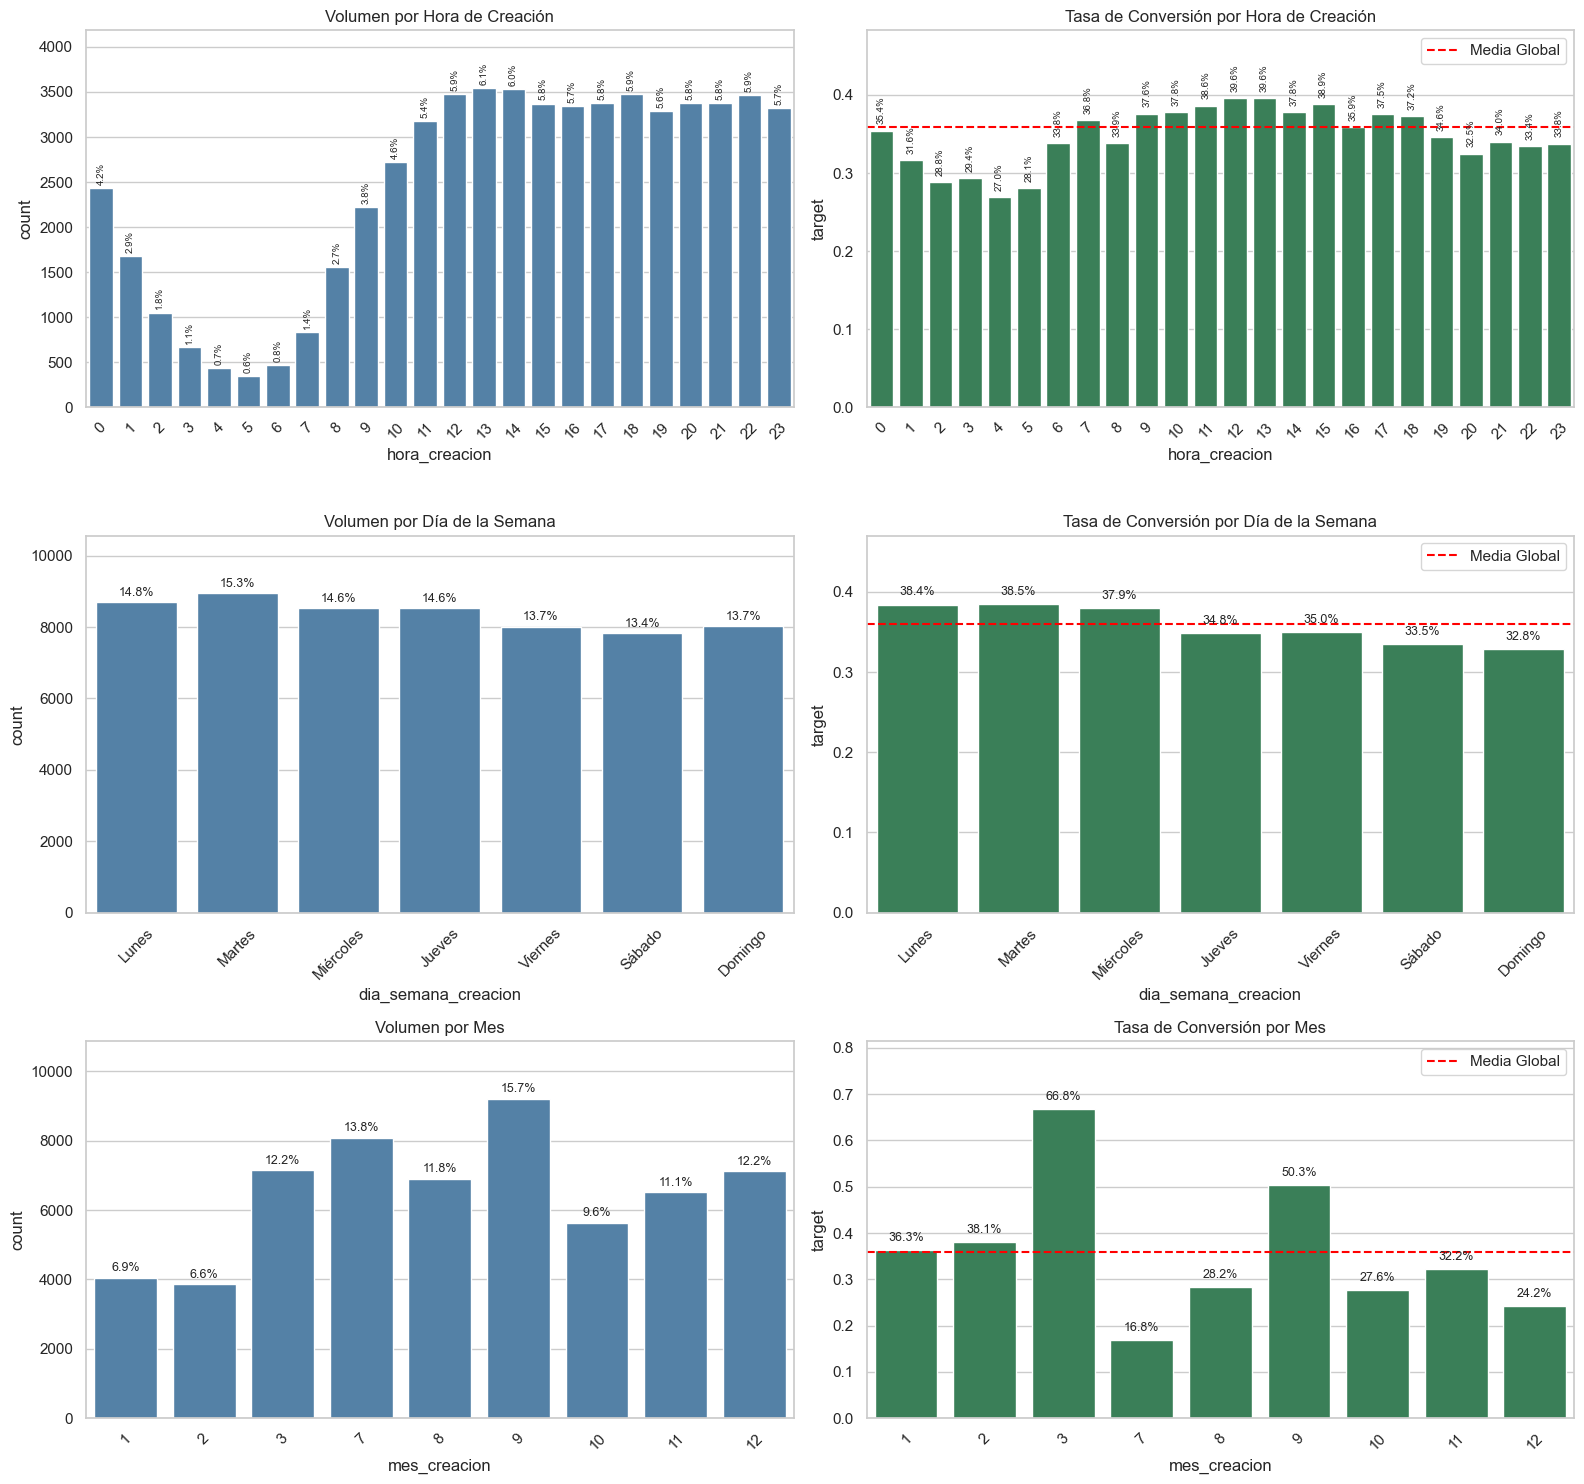

In [18]:
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
plt.subplots_adjust(hspace=0.55)

cols_temp = ['hora_creacion', 'dia_semana_creacion', 'mes_creacion']
titulos = ['Hora de Creación', 'Día de la Semana', 'Mes']

for i, col in enumerate(cols_temp):
    if col not in df.columns:
        continue

    # Volumen
    ax_vol = axes[i, 0]
    order = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo'] if col == 'dia_semana_creacion' else None
    if col == 'dia_semana_creacion':
        df['dia_semana_creacion'] = df['dia_semana_creacion'].str.capitalize()

    sns.countplot(data=df, x=col, color='steelblue', order=order, ax=ax_vol)
    ax_vol.set_title(f'Volumen por {titulos[i]}')
    ax_vol.tick_params(axis='x', rotation=45)

    # Porcentajes Volumen
    total = len(df)
    max_vol = max([p.get_height() for p in ax_vol.patches] + [0])
    ax_vol.set_ylim(0, max_vol * 1.18 if max_vol > 0 else 1)

    for p in ax_vol.patches:
        height = p.get_height()
        if pd.isna(height) or height <= 0:
            continue

        percentage = f'{100 * height / total:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = height + (max_vol * 0.01)

        is_hour_plot = col == 'hora_creacion'
        ax_vol.annotate(
            percentage,
            (x, y),
            ha='center',
            va='bottom',
            fontsize=7 if is_hour_plot else 9,
            rotation=90 if is_hour_plot else 0,
            clip_on=False,
        )

    # Tasa de conversión
    ax_conv = axes[i, 1]
    conv = df.groupby(col)['target'].mean().reset_index()
    sns.barplot(data=conv, x=col, y='target', color='seagreen', order=order, ax=ax_conv)
    ax_conv.set_title(f'Tasa de Conversión por {titulos[i]}')
    ax_conv.axhline(df['target'].mean(), color='red', linestyle='--', label='Media Global')
    ax_conv.tick_params(axis='x', rotation=45)
    ax_conv.legend()

    # Porcentajes Conversión
    max_conv = max([p.get_height() for p in ax_conv.patches] + [0])
    ax_conv.set_ylim(0, max(max_conv * 1.22, 0.05))

    for p in ax_conv.patches:
        val = p.get_height()
        if pd.isna(val) or val <= 0:
            continue

        percentage = f'{val * 100:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = val + (max_conv * 0.02)

        is_hour_plot = col == 'hora_creacion'
        ax_conv.annotate(
            percentage,
            (x, y),
            ha='center',
            va='bottom',
            fontsize=7 if is_hour_plot else 9,
            rotation=90 if is_hour_plot else 0,
            clip_on=False,
        )

plt.tight_layout()
plt.show()

**Hallazgos por variable temporal:**

**Por Hora:**
El volumen de leads sigue una curva de campana que pica en horario comercial (10 AM – 5 PM), lo cual coincide con la actividad normal de un cliente buscando un vehículo. La tasa de conversión, sin embargo, se mantiene relativamente estable a lo largo del día, indicando que **la hora no es un predictor lineal fuerte de conversión** por sí sola (aunque sí lo es en combinación con el día, como veremos en los Heatmaps).

**Por Día de la Semana:**
El volumen cae drásticamente los sábados y domingos (los concesionarios tienen menor atención). La tasa de conversión muestra diferencias frente a los días laborables, por lo que conviene tratar el fin de semana como una señal potencial y validarla en el modelado, en lugar de asumir una mejora uniforme.

**Por Mes:**
Los meses excluidos (Abril, Mayo, Junio) no aparecen, confirmando el filtro del Data Engineering. Los meses visibles muestran el volumen operativo real de la flota comercial a lo largo del año 2025.

**Diferencias V1 vs V2:**
En la V1, la extracción de hora se hacía sobre `Fecha de creación` (timestamp del sistema), haciendo que la mayoría de los leads mostraran hora 00:00. Esto ocultaba completamente los patrones horarios. En la V2, usando `Fecha de creación por el cliente`, recuperamos la distribución horaria real. La gráfica de día de la semana también cambia drásticamente: en la V1 el chatbot operaba los 7 días de forma uniforme, desdibujando la caída natural de los fines de semana.

## 4. Análisis de Variables Categóricas Principales

Se analizan las variables categóricas con mayor poder discriminativo para la conversión: **origen del lead, campaña de marketing, concesionario asignado y formulario de captación**. Para cada una se muestra el Top 10 por volumen (izquierda) y la tasa de conversión de cada categoría (derecha), con la línea roja indicando la media global (~38%).

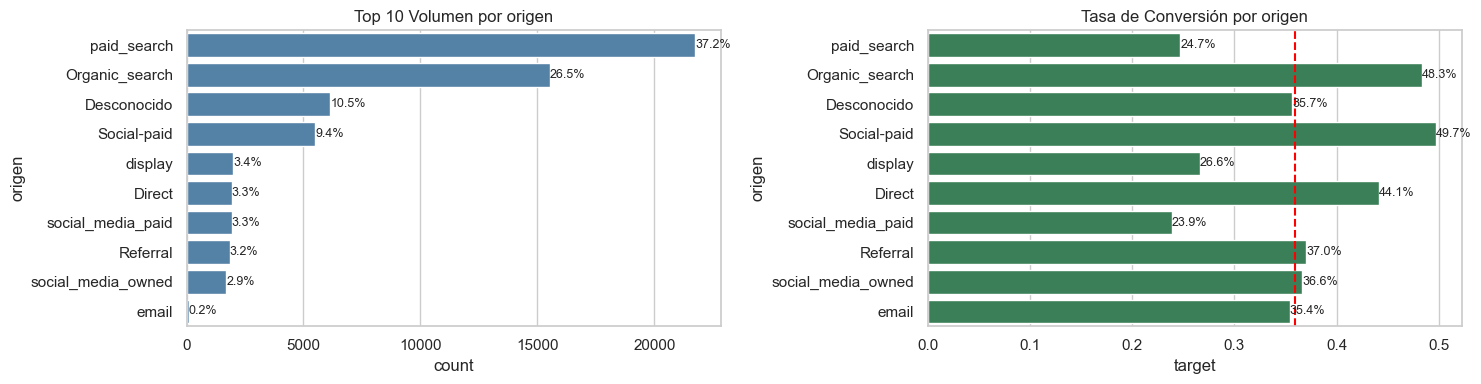

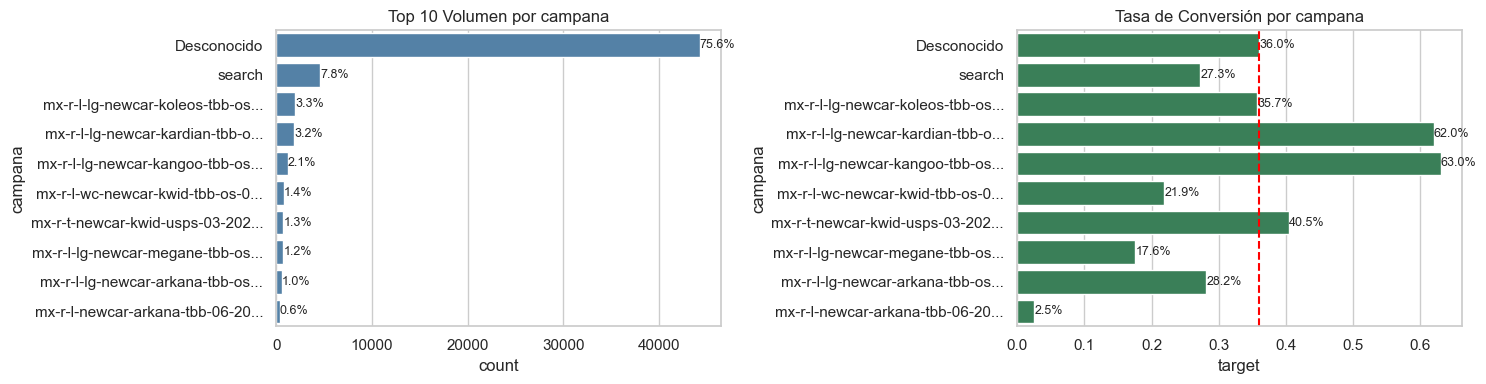

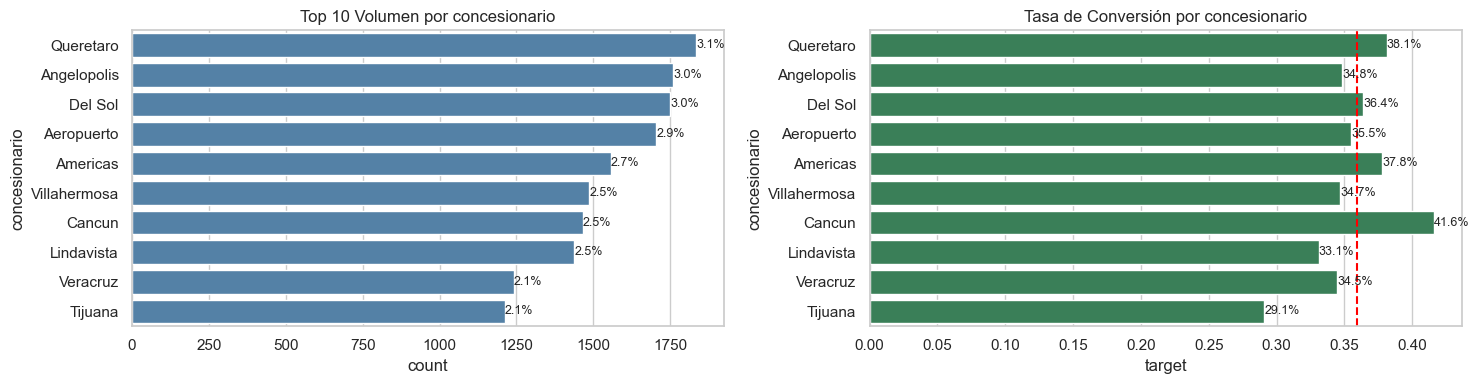

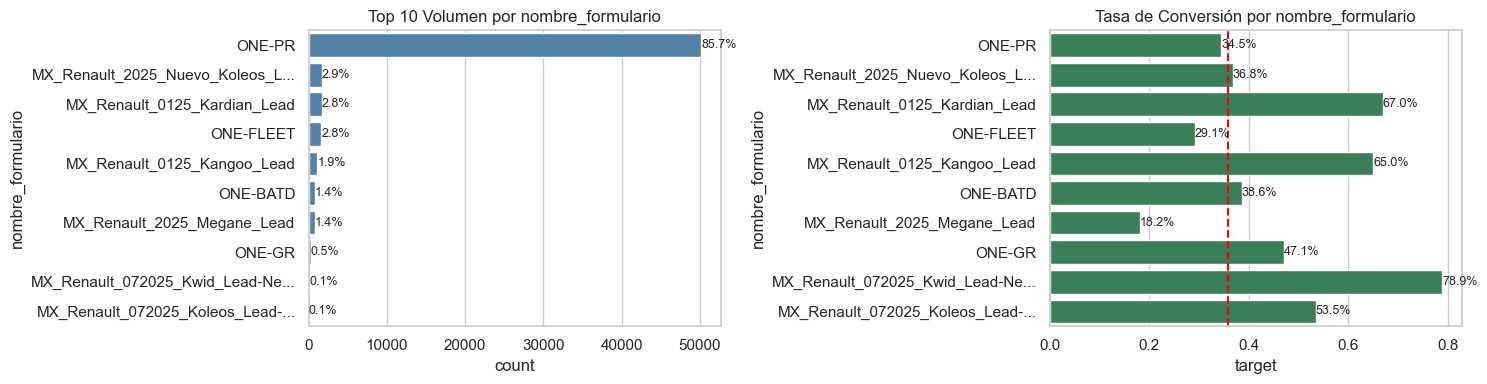

In [19]:
variables_cat = ['origen', 'campana', 'concesionario', 'nombre_formulario']
for col in variables_cat:
    if col not in df.columns: continue
    
    # Truncar nombres muy largos para que se vean en los gráficos
    df[col] = df[col].astype(str).apply(lambda x: x[:30] + '...' if len(x) > 30 else x)
    
    top_10 = df[col].value_counts().nlargest(10).index
    df_top = df[df[col].isin(top_10)]
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    plt.subplots_adjust(wspace=0.3, left=0.15)
    
    # Volumen
    sns.countplot(data=df_top, y=col, order=top_10, color='steelblue', ax=axes[0])
    axes[0].set_title(f'Top 10 Volumen por {col}')
    
    # Tasa de Conversión
    conv = df_top.groupby(col)['target'].mean().reindex(top_10).reset_index()
    sns.barplot(data=conv, y=col, x='target', color='seagreen', ax=axes[1])
    axes[1].set_title(f'Tasa de Conversión por {col}')
    axes[1].axvline(df['target'].mean(), color='red', linestyle='--', label='Media Global')
    
    total = len(df)
    for p in axes[0].patches:
        width = p.get_width()
        if np.isnan(width): width = 0
        percentage = f'{100 * width / total:.1f}%'
        x = width
        y = p.get_y() + p.get_height() / 2
        axes[0].annotate(percentage, (x, y), ha='left', va='center', fontsize=9)

    for p in axes[1].patches:
        val = p.get_width()
        if np.isnan(val): val = 0
        percentage = f'{val*100:.1f}%'
        x = val
        y = p.get_y() + p.get_height() / 2
        axes[1].annotate(percentage, (x, y), ha='left', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

**Hallazgos por variable categórica:**

**Origen del lead:**
Los orígenes con mayor volumen (como formularios de la web o landing pages) no siempre son los de mayor conversión. Orígenes de nicho o especializados (como referidos o eventos) suelen tener tasas de conversión muy superiores a la media.

**Campaña:**
Se observa el fenómeno clásico de Marketing digital: pocas campañas concentran la mayoría del volumen, pero con tasas de conversión bajas (tráfico masivo y frío). Otras campañas más específicas tienen volumen reducido pero una conversión sobresaliente. El modelo deberá capturar esta relación no lineal entre campaña y conversión.

**Concesionario:**
Las tasas de conversión varían significativamente entre concesionarios, reflejando diferencias en la eficiencia del equipo de ventas, la zona geográfica y el tipo de producto que comercializan.

**Nombre del formulario:**
Los formularios de captura tienen perfiles de calidad muy distintos: formularios de comparación de precios o configuradores generan leads de alta conversión, mientras que formularios de suscripción o brochures atraen leads más exploratorios.

**Diferencias V1 vs V2:**
En la V1, la variable `plataforma` mostraba en esta sección que el chatbot era responsable de un enorme volumen con conversión casi nula, "revelando" el bot al modelo como una señal de baja calidad. Al eliminarlo en V2, el análisis de categorías muestra únicamente el comportamiento humano, y variables como `campana` y `concesionario` emergen con mayor fuerza predictiva real. Además, en V1 se usaba One-Hot Encoding generando decenas de columnas. En V2 usaremos Target Encoding con Bayesian Smoothing para capturar estas relaciones de forma densa y sin explosión de dimensionalidad.

## 5. Análisis Temporal Detallado (Heatmaps)

Los heatmaps cruzados permiten visualizar simultáneamente **dos dimensiones temporales** (día de la semana vs. hora del día) para descubrir patrones que no son visibles en los gráficos simples por separado. Se generan dos heatmaps:
1. **Volumen de leads** por combinación día-hora (¿cuándo llegan más leads?)
2. **Tasa de conversión** por combinación día-hora (¿cuándo convierten mejor?)

La comparación entre ambos es la clave: un bloque con alto volumen pero baja conversión es tráfico frío; un bloque con poco volumen pero alta conversión es tráfico caliente muy valioso.

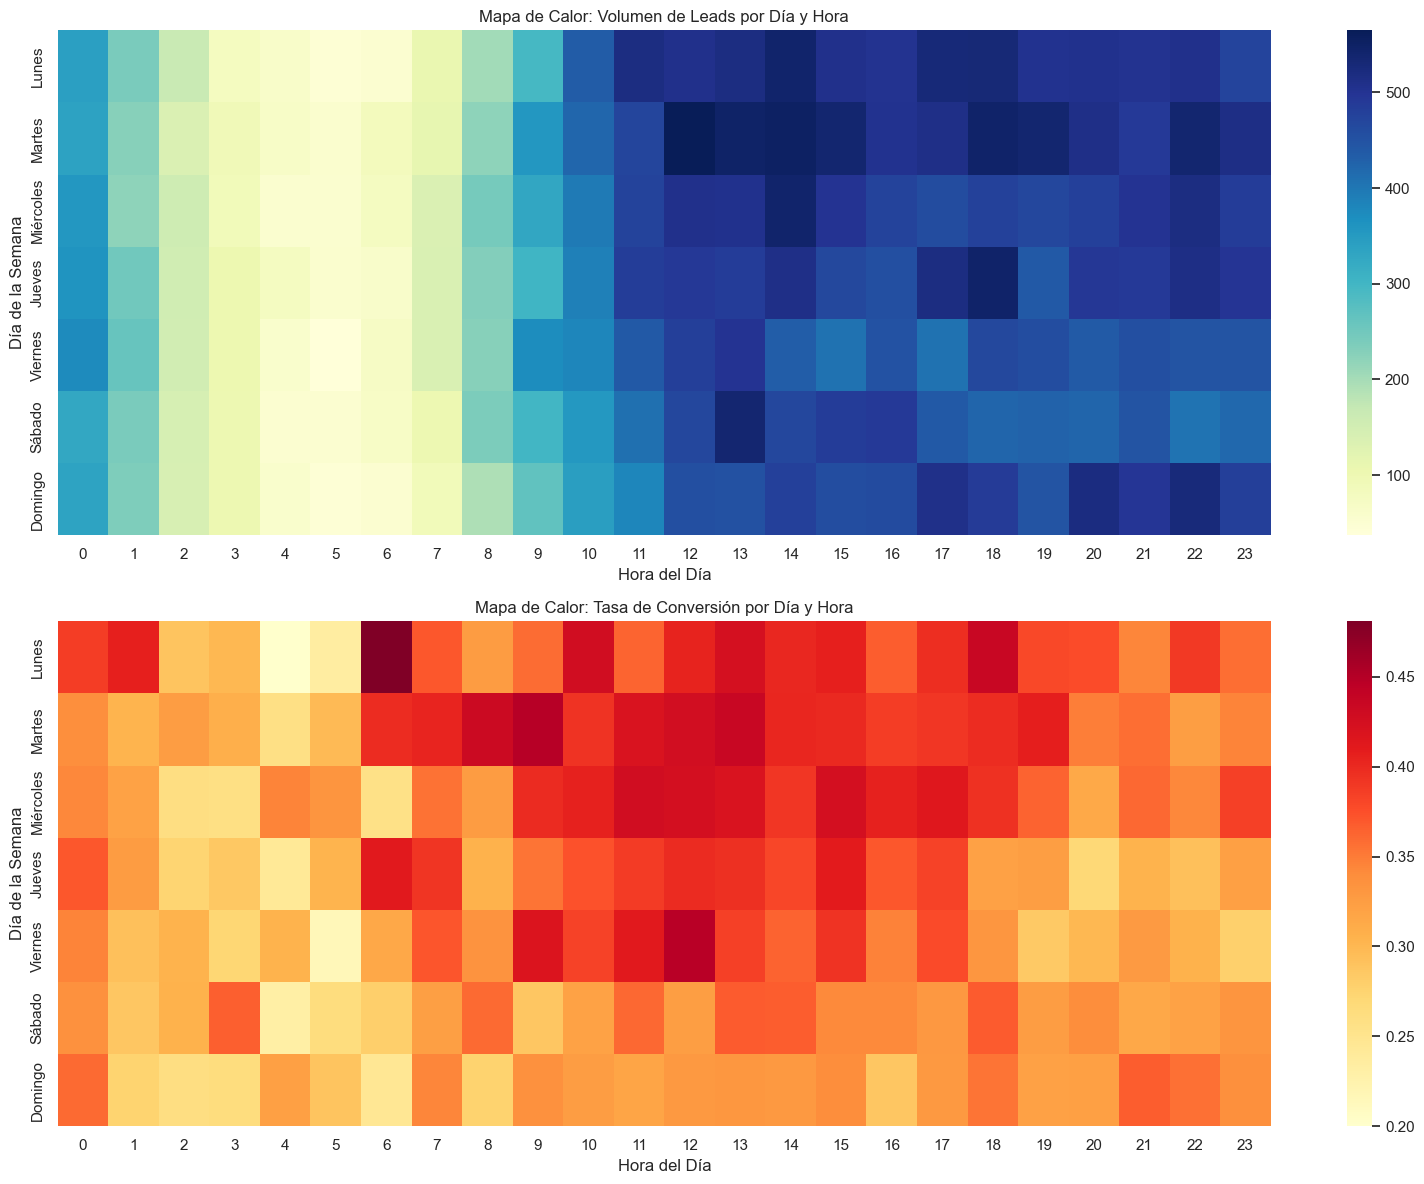

In [20]:
pivot_vol = df.pivot_table(index='dia_semana_creacion', columns='hora_creacion', values='target', aggfunc='count', fill_value=0)
pivot_conv = df.pivot_table(index='dia_semana_creacion', columns='hora_creacion', values='target', aggfunc='mean', fill_value=0)

dias_orden = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
pivot_vol = pivot_vol.reindex(dias_orden)
pivot_conv = pivot_conv.reindex(dias_orden)

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

sns.heatmap(pivot_vol, cmap="YlGnBu", annot=False, ax=axes[0])
axes[0].set_title("Mapa de Calor: Volumen de Leads por Día y Hora")
axes[0].set_xlabel("Hora del Día")
axes[0].set_ylabel("Día de la Semana")

sns.heatmap(pivot_conv, cmap="YlOrRd", annot=False, ax=axes[1])
axes[1].set_title("Mapa de Calor: Tasa de Conversión por Día y Hora")
axes[1].set_xlabel("Hora del Día")
axes[1].set_ylabel("Día de la Semana")

plt.tight_layout()
plt.show()

**Hallazgos del Heatmap de Volumen:**
El mapa azul muestra clústeres oscuros muy marcados de **Lunes a Viernes entre las 9:00 y las 19:00 horas**, que corresponde al horario operativo de los concesionarios. Los fines de semana presentan un volumen considerablemente menor pero no nulo, reflejando que algunos clientes investigan activamente durante su tiempo libre. La madrugada (0-7 AM) es prácticamente nula para todos los días, lo cual confirma que los leads de chatbot (que sí aparecían en estas franjas) han sido correctamente eliminados.

**Hallazgos del Heatmap de Conversión:**
El mapa rojo revela algo estratégicamente valioso: **los picos de conversión no se alinean perfectamente con los picos de volumen**. Existen franjas horarias con menor volumen donde la tasa de conversión cambia de forma visible, lo que sugiere que la relación entre hora y conversión no es lineal y debe capturarse con variables derivadas o modelos no lineales.

**Diferencias V1 vs V2:**
En la V1, los heatmaps estaban completamente distorsionados: el chatbot operaba en lotes nocturnos, creando franjas de alta densidad artificiales en horas imposibles (2-5 AM). Además, la extracción incorrecta de la hora sobre la columna del sistema hacía que la mayoría de los registros cayeran en la hora 0, generando una columna vertical de madrugada sin sentido comercial. En la V2, ambos problemas están corregidos, y el heatmap refleja la realidad operativa del negocio.

## 6. Correlación entre Variables Numéricas

La matriz de correlación mide la **relación lineal** entre las variables numéricas del dataset y con la variable objetivo `target`. Es útil para detectar features redundantes (alta correlación entre sí) y para entender qué variables tienen alguna relación lineal directa con la conversión.

> ⚠️ **Nota:** Una correlación lineal baja no significa que la variable sea inútil. Los modelos de árboles (como XGBoost o LightGBM) pueden capturar relaciones no lineales complejas que la correlación de Pearson no detecta.

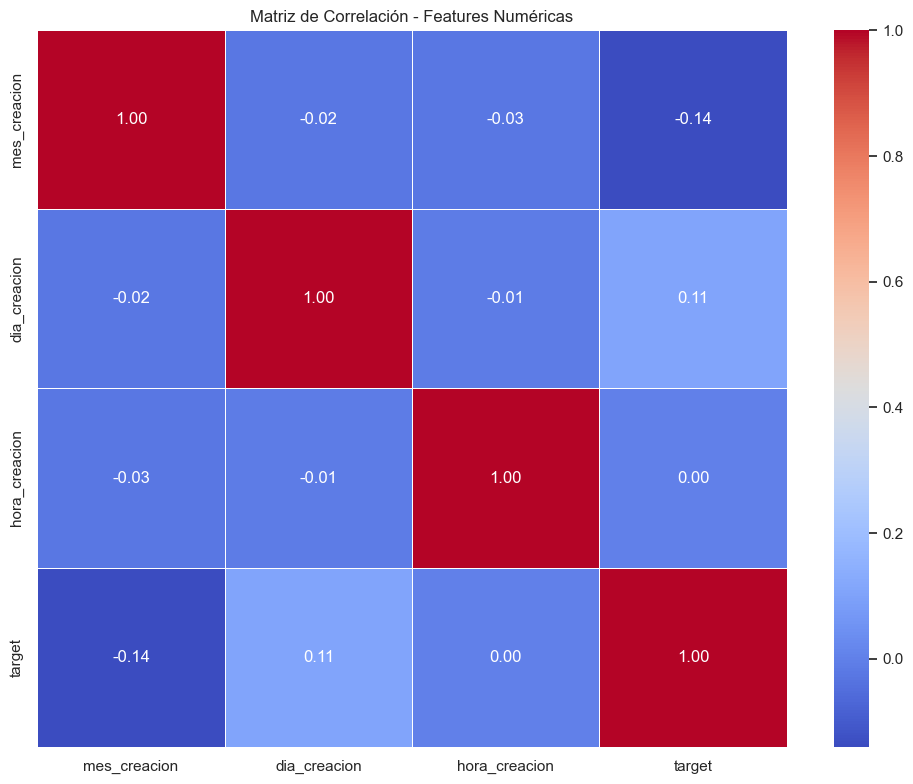

In [21]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación - Features Numéricas")
plt.tight_layout()
plt.show()

**Hallazgos de la Matriz de Correlación:**
Al analizar la relación de las variables temporales numéricas con el Target (1=Hot, 0=Cold):
- **`mes_creacion` (~-0.20):** Correlación negativa leve. Los meses iniciales del año tienen mayor tasa de conversión, que decrece ligeramente hacia finales de año. Puede estar relacionado con ciclos de ventas automotrices (inicio de año, renovación de flota).
- **`dia_creacion` (~0.14):** Correlación positiva leve. Leads hacia finales de mes tienen marginalmente mayor conversión, posiblemente relacionado con cierres de quincena o mes del equipo comercial.
- **`hora_creacion` (~0.00):** Sin correlación lineal significativa. Esto es esperado: la hora importa, pero de forma no lineal (ciertos bloques horarios son mejores, no hay una tendencia lineal creciente o decreciente). 
- **Entre variables numéricas:** Las variables temporales no están correlacionadas entre sí, lo que es ideal: cada una aporta información independiente al modelo.

**Diferencias V1 vs V2:**
En esta V2, la lectura de correlaciones es más interpretable porque las variables temporales ya no están distorsionadas por una extracción horaria incorrecta ni por el sesgo operativo del chatbot.


## 7. Hallazgos Clave del EDA y Recomendaciones para Feature Engineering

---
### Resumen de Hallazgos

**1. TARGET**
- Distribución real: ~38% Hot Leads / ~62% Cold Leads (sin sesgo de chatbot)
- Desbalance moderado: no exige oversampling; `class_weight='balanced'` puede evaluarse como ajuste opcional
- Métrica principal: ROC-AUC, complementada con F1-Score

**2. FEATURES TEMPORALES**
- `hora_creacion`: ahora refleja horas reales (no 00:00). Relación no lineal con conversión 
- `dia_semana_creacion`: fines de semana tienen menor volumen y una tasa de conversión diferenciada frente a los días laborables
- `mes_creacion`: ligera tendencia estacional; meses iniciales con mayor conversión

**3. FEATURES CATEGÓRICAS**
- Alta cardinalidad en `campana`, `concesionario`, `nombre_formulario`: One-Hot Encoding causaría explosión de dimensionalidad
- Relación no lineal entre volumen y conversión: categorías con alto volumen no siempre convierten mejor
- Ajuste de % altos en algunos indicadores: **Target Encoding con Bayesian Smoothing**, para no entorpecer el modelo

---
### A tener en cuenta para Feature Engineering (Notebook 02)

| Acción | Variable(s) | Motivo |
|--------|------------|--------|
| Revisar | `subtipo_interes` | Sigue presente en V2; validar si fue completada post-llamada para descartar data leakage antes de usarla o eliminarla |
| Crear | `es_fin_de_semana` | Captura el comportamiento diferencial del lead de fin de semana |
| Crear | `franja_horaria` | Agrupa horas en bloques (madrugada/mañana/tarde/noche) |
| Target Encode | `campana`, `concesionario`, `origen`, `nombre_formulario` | Alta cardinalidad; aplicar Bayesian Smoothing para evitar sobreajuste |
| Conservar | `hora_creacion`, `mes_creacion`, `dia_creacion` | Relación no lineal. Sirve tambien para analisis del comportamiento de las campañas.  |
